In [1]:
import os

import networkx as nx
import numpy as np
import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams
import synapseclient
from synapseclient.entity import File as sceFile

# set max font size 
rcParams["font.size"] = 7

In [2]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse ID for the combined data table
COMBINED_TABLE_SYN_ID = "syn74775996"

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITD-WT.arrow": "syn74776638",
    "B_FLT3-ITD-WT.csv": "syn74776648",
    "B_FLT3-ITD-WT_mut-cols.txt": "syn74776635",
    "B_FLT3-ITD-WT_wt-cols.txt": "syn74776634",
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITD-WT.arrow": "syn74776654",
    "W_FLT3-ITD-WT.csv": "syn74776655",
    "W_FLT3-ITD-WT_mut-cols.txt": "syn74776647",
    "W_FLT3-ITD-WT_wt-cols.txt": "syn74776646",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# cached table with top up and down features, apache arrow format, on synapse 
TOP_FEATURES_SYNID = "syn74782709"

CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache"
)

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "lipids"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

In [4]:
# ensure diffex and figure directories exist
os.makedirs(FIGURE_DIR, exist_ok=True)

In [3]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.13.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.13.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



In [48]:
# load the dataset
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

df = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Lipidomics")
    .drop("Block")
    .rename({"Feature": "Lipid"})
    .unpivot(
        index="Lipid",
        variable_name="Sample",
        value_name="Z-score"
    )
    .with_columns(
        (
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols + b_wt_cols
                } | {
                    k: "NPM1"
                    for k in w_mut_cols + b_mut_cols
                }
            )
            .alias("Mutation")
        ),
        (
            pl.col("Sample")
            .replace(
                {
                    k: "black"
                    for k in b_wt_cols + b_mut_cols
                } | {
                    k: "white"
                    for k in w_wt_cols + w_mut_cols
                }
            )
            .alias("Race")
        )
    )
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Lipid", "Race", "Mutation")
    .agg("Z-score")
    .pivot(
        on="Mutation", 
        index=["Lipid", "Race"],
        values="Z-score",
    )
    .with_columns(
        # strip ionization mode off of the front and adduct off of the back of lipid IDs
        # and keep only the last annotation if multiple separated by |
        (
            pl.col("Lipid")
            .str.replace("[posneg]{3}_", "")
            .str.replace(r"_\[M[+-][H2ON4-]+\][+-].*", "")
            .str.split("|")
            .list.last()
            .str.replace("__[A-Z]+", "")
        ) + " " + (
            pl.col("Lipid")
            .str.extract(r"(\[M[+-][H2ON4-]+\][+-])")
            .fill_null("[M+H-H2O]+")
        )
    )
    .with_columns(
        (
            (
                pl.col("NPM1").list.mean() - pl.col("WT").list.mean()
            )
            .alias("Delta-Z")
        ),
        (
            pl.struct("WT", "NPM1")
            .map_elements(
                lambda x: stats.ttest_ind(
                    x["WT"], 
                    x["NPM1"], 
                    equal_var=False  # Welch's t-test
                ).pvalue,  # type: ignore
                return_dtype=pl.Float64
            )
            .alias("TTest-P")
        )
    )
    .filter(pl.col("TTest-P") <= 0.05)
)
df

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23623/3434652576.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23623/3434652576.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23623/3434652576.py:6: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23623/3434652576.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23623/3434652576.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Lipid,Race,NPM1,WT,Delta-Z,TTest-P
str,str,list[f64],list[f64],f64,f64
"""PI 18:1_22:5 [M-H]-""","""black""","[-0.307036, -1.619136, … -0.082639]","[-0.707625, 0.38805, … -1.145995]",-0.675695,0.006275
"""PE 16:0_16:1 [M-H]-""","""white""","[-1.499606, 0.384495, … 0.855614]","[0.828407, 0.935686, … -1.673687]",-1.000415,0.036156
"""PC 18:1_20:4 [M+H]+""","""black""","[-0.158329, 1.323391, … -0.50402]","[-1.007287, 1.444727, … -0.422208]",0.598299,0.046645
"""PE P-18:1_20:4 [M+H]+""","""black""","[0.14873, 0.878107, … 0.845647]","[0.10074, -0.36671, … -1.281226]",0.644969,0.011848
"""Hex3Cer 18:1;O2/24:1 [M+H]+""","""white""","[-0.850297, -0.59691, … -1.841228]","[0.264564, 0.328573, … 0.314362]",-0.909642,0.00701
…,…,…,…,…,…
"""PE 16:1_20:4 [M-H]-""","""black""","[1.569649, 0.671835, … -0.256666]","[-1.702495, -0.51313, … -0.268898]",1.001596,0.007405
"""PG 20:4_22:6 [M-H]-""","""black""","[-0.622988, -0.155464, … -0.33922]","[0.347396, 0.749373, … -0.899428]",-0.713401,0.00014
"""PI 18:2_18:2 [M-H]-""","""black""","[-0.600279, -1.375195, … 0.561778]","[-1.248855, 0.362043, … 1.025065]",-0.603577,0.035614


In [52]:
with pl.Config(set_tbl_rows=50):
    display(
        df
        .filter(pl.col("Race") == "black")
        .sort("Delta-Z")
    )

Lipid,Race,NPM1,WT,Delta-Z,TTest-P
str,str,list[f64],list[f64],f64,f64
"""CE 18:1 [M+NH4]+""","""black""","[-1.708805, -1.384679, … 0.959738]","[-0.842785, -0.396315, … 0.479436]",-0.987268,0.044592
"""PI 18:1_18:2 [M-H]-""","""black""","[-2.059174, -1.617327, … -0.008715]","[-0.559845, 0.155313, … -0.167925]",-0.903976,0.001465
"""LPI 18:1 [M-H]-""","""black""","[-2.863016, -0.574443, … -0.328055]","[-0.192176, -0.679443, … 0.469841]",-0.870219,0.02412
"""HexCer 18:1;O2/22:1 [M+H-H2O]+""","""black""","[-0.15686, -1.119751, … -0.033308]","[-0.101676, 0.090431, … -2.8121]",-0.772609,0.017725
"""LPE 20:2 [M-H]-""","""black""","[0.878495, -1.930045, … -1.108334]","[0.149748, -0.618175, … 0.884547]",-0.763666,0.019509
"""PG 18:2_22:6 [M-H]-""","""black""","[-1.386625, -0.384525, … -0.474804]","[0.674639, 1.485179, … -1.487843]",-0.714072,0.006786
"""PG 20:4_22:6 [M-H]-""","""black""","[-0.622988, -0.155464, … -0.33922]","[0.347396, 0.749373, … -0.899428]",-0.713401,0.00014
"""Cer 18:1;O2/22:2 [M+H-H2O]+""","""black""","[0.393832, -1.211012, … 0.839193]","[-1.038179, 0.305026, … 0.042846]",-0.688707,0.027659
"""PI 18:1_22:5 [M-H]-""","""black""","[-0.307036, -1.619136, … -0.082639]","[-0.707625, 0.38805, … -1.145995]",-0.675695,0.006275


In [53]:
with pl.Config(set_tbl_rows=50):
    display(
        df
        .filter(pl.col("Race") == "white")
        .sort("Delta-Z")
    )

Lipid,Race,NPM1,WT,Delta-Z,TTest-P
str,str,list[f64],list[f64],f64,f64
"""PE 16:0_16:1 [M-H]-""","""white""","[-1.499606, 0.384495, … 0.855614]","[0.828407, 0.935686, … -1.673687]",-1.000415,0.036156
"""PI 18:1_22:5 [M-H]-""","""white""","[-0.284216, -0.942742, … -1.955459]","[0.418447, 0.179615, … -0.089113]",-0.966815,0.001817
"""Hex3Cer 18:1;O2/24:1 [M+H]+""","""white""","[-0.850297, -0.59691, … -1.841228]","[0.264564, 0.328573, … 0.314362]",-0.909642,0.00701
"""LPG 18:0 [M-H]-""","""white""","[-0.214526, -1.255442, … 1.220584]","[-1.316757, 0.613966, … -0.648909]",-0.79278,0.037456
"""PI 18:1_22:6 [M-H]-""","""white""","[-0.452932, -1.495717, … -0.559939]","[0.813278, 0.596004, … -0.107225]",-0.751682,0.046519
"""LPC 22:5/0:0 [M+H]+""","""white""","[-0.385075, -1.128677, … 1.115827]","[-1.77279, 1.012463, … -2.07938]",-0.670297,0.033032
"""Cer 18:1;O2/18:0 [M+H-H2O]+""","""white""","[-0.155896, 0.490264, … 0.800726]","[1.880321, -4.058151, … 1.552163]",0.465044,0.040169
"""PE P-16:0_18:1 [M+H]+""","""white""","[0.506997, 1.036299, … -0.415365]","[1.634, -2.469645, … 1.387867]",0.519389,0.036605
"""PG 18:1_18:2 [M-H]-""","""white""","[0.366174, 0.945468, … 0.747166]","[-0.752675, 0.563859, … 1.600634]",0.539191,0.019353


---

In [138]:
def swarm(
    ax,
    x_center, 
    values,
    c,
    sd=0.1
):
    x = np.random.normal(x_center, sd, size=len(values))
    ax.scatter(
        x, 
        values,
        marker=".",
        s=1,
        c=c
    )

In [104]:
C = {
    "swarm": {
        ("black", "WT"): "#7D7B8D",
        ("black", "NPM1"): "#F3858E",
        ("black", "NPM1+FLT3_ITD"): "#F3858E",
        ("white", "WT"): "#81B0F2",
        ("white", "NPM1"): "#EFDA85",
        ("white", "NPM1+FLT3_ITD"): "#EFDA85",
    },
    "bar": {
        ("black", "WT"): "#53516A",
        ("black", "NPM1"): "#E84855",
        ("black", "NPM1+FLT3_ITD"): "#E84855",
        ("white", "WT"): "#3185FC",
        ("white", "NPM1"): "#E3B505",
        ("white", "NPM1+FLT3_ITD"): "#E3B505",
    }
}

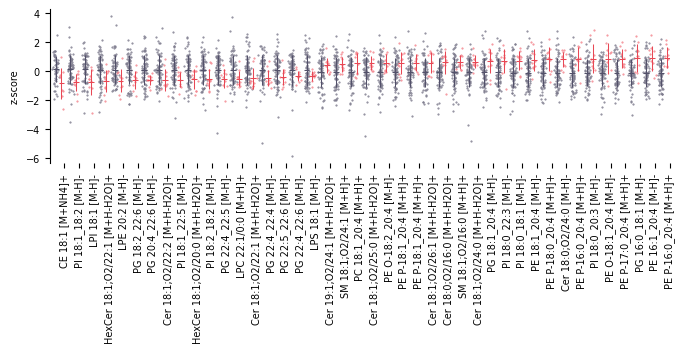

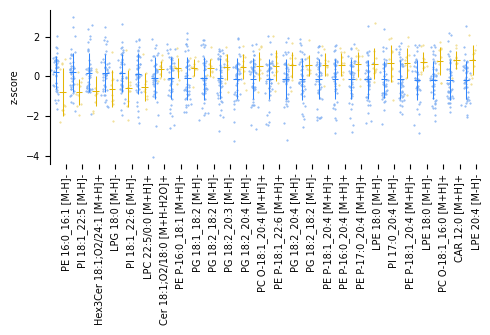

In [90]:
for race in ["black", "white"]:
    fig, ax = plt.subplots(
        figsize=({"black": 8, "white": 5.5}[race], 2)
    )

    x_off = 0.4
    bw = 0.2

    #ax.axhline(c="k", lw=1., zorder=-1)
    _df = (
        df
        .filter(pl.col("Race") == race)
        .sort("Delta-Z")
        .drop("Race", "TTest-P", "Delta-Z")
    )

    for x_center, (lipid, mut, wt)  in enumerate(_df.iter_rows()):
        x_center = x_center + 1 - 1.5 * x_off
        zs = {"WT": wt, "NPM1": mut}
        for mut in ["WT", "NPM1"]:
            ax.errorbar(
                x_center,
                np.mean(zs[mut]),
                yerr=np.std(zs[mut]),
                xerr=bw,
                ecolor=C["bar"][(race, mut)],
                elinewidth=0.75
            )
            swarm(ax, x_center, zs[mut], C["swarm"][(race, mut)])
            x_center += x_off
            
    for d in ["top", "right", "bottom"]:
        ax.spines[d].set_visible(False)

    ax.set_xlim((0, len(_df)))
    ax.set_xticks([_ + 1 for _ in range(len(_df))])
    ax.set_xticklabels(_df["Lipid"], rotation=90)

    ax.set_ylabel("z-score")

    plt.savefig(
        os.path.join(FIGURE_DIR, f"z_score_bar_swarms_{race}.png"),
        dpi=400,
        transparent=True,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

In [93]:
(
    df
    .filter(pl.col("Race") == "black")
    .select("Lipid", "Delta-Z")
    .sort("Lipid")
)

Lipid,Delta-Z
str,f64
"""CE 18:1 [M+NH4]+""",-0.987268
"""Cer 18:0;O2/16:0 [M+H-H2O]+""",0.70539
"""Cer 18:0;O2/24:0 [M-H]-""",0.923634
"""Cer 18:1;O2/22:1 [M+H-H2O]+""",-0.591778
"""Cer 18:1;O2/22:2 [M+H-H2O]+""",-0.688707
…,…
"""PI 18:1_18:2 [M-H]-""",-0.903976
"""PI 18:1_22:5 [M-H]-""",-0.675695
"""PI 18:2_18:2 [M-H]-""",-0.603577


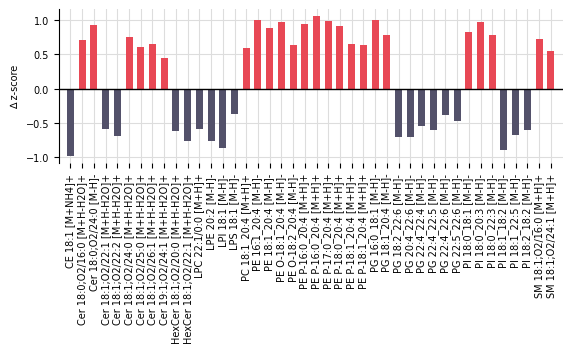

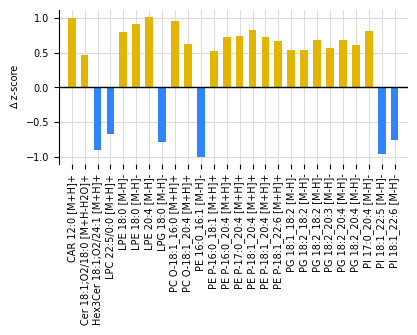

In [107]:
for race in ["black", "white"]:
    fig, ax = plt.subplots(
        figsize=({"black": 6.5, "white": 4.5}[race], 2)
    )

    bw = 0.6

    
    
    _df = (
        df
        .filter(pl.col("Race") == race)
        .select("Lipid", "Delta-Z")
        .sort("Lipid")  
    )

    x = [_ + 1 for _ in range(len(_df))]
    c = [
        C["bar"][(race, ("NPM1" if dz > 0 else "WT"))]
        for dz in _df["Delta-Z"]
    ]
    ax.bar(
        x,
        _df["Delta-Z"],
        color=c,
        width=bw,
        zorder=10,
    )
            
    for d in ["top", "right", "bottom"]:
        ax.spines[d].set_visible(False)

    ax.set_xlim((0, len(_df) + 1))
    ax.set_xticks(x)
    ax.set_xticklabels(_df["Lipid"], rotation=90)

    ax.grid(which="major", color="#DDDDDD")

    ax.axhline(c="k", lw=1., zorder=11)

    ax.set_ylabel("∆ z-score")

    plt.savefig(
        os.path.join(FIGURE_DIR, f"z_score_bars_{race}.png"),
        dpi=400,
        transparent=True,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

Sphingolipids with VLCFAs

In [27]:
sphingo_genes = [
    # elongase for making VLCFAs
    "ELOVL1", "ELOVL7", "HACD2",
    # VLCFA catabolism
    "ABCD1", "ACOX1",
    # ceramide synthase
    "CERS2", "CERS4", "CERS5", "CERS6",
    # ceramidase
    "ASAH1", "ASAH2",
    # sphingolipid desaturase
    "DEGS1",
    # serine palmitoyltransferase
    "SPTLC1", "SPTLC2",
    # sphingomyelin synthase
    "SGMS1", "SGMS2",
    # sphingomyelinase
    "SMPD1", "SMPD2", "SMPD3", 
]

In [28]:
# load the dataset
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

ddf = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(sphingo_genes)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
ddf

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/985513662.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/985513662.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/985513662.py:6: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/985513662.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/985513662.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""ELOVL1""","""14-00240""",null,"""WT""","""black"""
"""SPTLC1""","""14-00240""",null,"""WT""","""black"""
"""CERS4""","""14-00240""",null,"""WT""","""black"""
"""SPTLC2""","""14-00240""",null,"""WT""","""black"""
"""ABCD1""","""14-00240""",null,"""WT""","""black"""
…,…,…,…,…
"""ELOVL7""","""19-00092""",-0.210231,"""NPM1""","""white"""
"""SMPD1""","""19-00092""",-1.349589,"""NPM1""","""white"""
"""CERS6""","""19-00092""",0.521237,"""NPM1""","""white"""


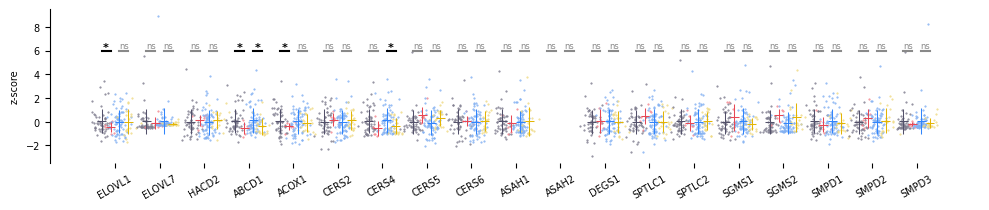

In [29]:
dzscores = (
    ddf
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)

dzsf = {
    (g, r, m): z
    for g, r, m, z in dzscores.iter_rows()
}

dpvf = {}
for gene in sphingo_genes:
    for race in ["black", "white"]:
        if (
            (zs_wt := dzsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := dzsf.get((gene, race, "NPM1"))) is not None
        ):
            dpvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

# # apply BH correction to ttest pvalues
# dpvf_keys, dpvf_values = map(list, zip(*dpvf.items()))
# dpvf = dict(zip(dpvf_keys, stats.false_discovery_control(dpvf_values)))

fig, ax = plt.subplots(
    figsize=(12, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(sphingo_genes):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := dzsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := dpvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(sphingo_genes))])
ax.set_xticklabels(sphingo_genes, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_tx_sphingo-genes.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [30]:
ddfp = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Proteomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(sphingo_genes)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
ddfp

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/1135049692.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_41871/1135049692.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""ABCD1""","""14-00240""",-0.480881,"""WT""","""black"""
"""ACOX1""","""14-00240""",-0.827233,"""WT""","""black"""
"""ASAH1""","""14-00240""",-1.124414,"""WT""","""black"""
"""CERS2""","""14-00240""",-1.644444,"""WT""","""black"""
"""CERS5""","""14-00240""",-1.624426,"""WT""","""black"""
…,…,…,…,…
"""HACD2""","""19-00092""",-0.205802,"""NPM1""","""white"""
"""SMPD1""","""19-00092""",-1.01729,"""NPM1""","""white"""
"""SMPD2""","""19-00092""",-0.59593,"""NPM1""","""white"""


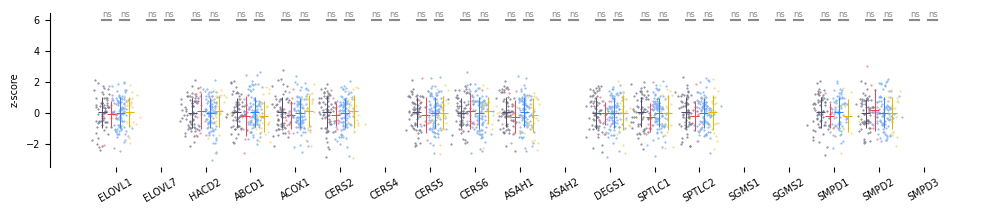

In [31]:
dzscores = (
    ddfp
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)

dzsf = {
    (g, r, m): z
    for g, r, m, z in dzscores.iter_rows()
}

dpvf = {}
for gene in sphingo_genes:
    for race in ["black", "white"]:
        if (
            (zs_wt := dzsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := dzsf.get((gene, race, "NPM1"))) is not None
        ):
            dpvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

# # apply BH correction to ttest pvalues
# dpvf_keys, dpvf_values = map(list, zip(*dpvf.items()))
# dpvf = dict(zip(dpvf_keys, stats.false_discovery_control(dpvf_values)))

fig, ax = plt.subplots(
    figsize=(12, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(sphingo_genes):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := dzsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := dpvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(sphingo_genes))])
ax.set_xticklabels(sphingo_genes, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_px_sphingo-genes.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

---

In [187]:
pufa_genes = [
    # elongases
    "ELOVL2", "ELOVL5",
    # desaturases
    "FADS1", "FADS2",
    # peroxisomal beta oxidation
    "ACOX1", "HSD17B4",
    # phospholipases
    "PLA2G4A", "PLA2G6",
    # FA CoA transferases
    "ACSL4", "ACSL6", 
    # acyltransferase
    "LPCAT3",
    # cyclooxygenases
    "COX1", "COX2",
    # lipoxygenases
    "ALOX5", "ALOX15", "ALOX15B",
    # anti-ferroptosis
    "GPX4", "FSP1"
]

In [188]:
# load the dataset
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

pdf = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(pufa_genes)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
pdf

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/747372414.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/747372414.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/747372414.py:6: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/747372414.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/747372414.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""ELOVL5""","""14-00240""",null,"""WT""","""black"""
"""ALOX5""","""14-00240""",null,"""WT""","""black"""
"""ACSL4""","""14-00240""",null,"""WT""","""black"""
"""LPCAT3""","""14-00240""",null,"""WT""","""black"""
"""PLA2G4A""","""14-00240""",null,"""WT""","""black"""
…,…,…,…,…
"""ALOX15""","""19-00092""",-0.176564,"""NPM1""","""white"""
"""ACSL6""","""19-00092""",-0.590208,"""NPM1""","""white"""
"""GPX4""","""19-00092""",-0.511782,"""NPM1""","""white"""


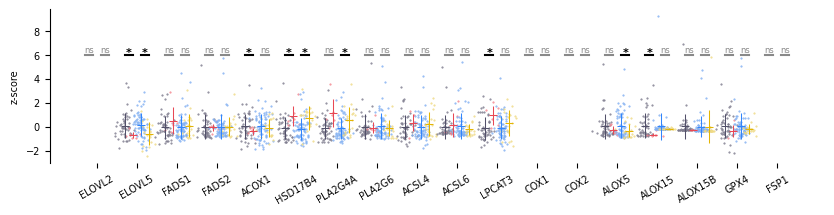

In [189]:
pzscores = (
    pdf
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)

pzsf = {
    (g, r, m): z
    for g, r, m, z in pzscores.iter_rows()
}

ppvf = {}
for gene in pufa_genes:
    for race in ["black", "white"]:
        if (
            (zs_wt := pzsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := pzsf.get((gene, race, "NPM1"))) is not None
        ):
            ppvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

# # apply BH correction to ttest pvalues
# dpvf_keys, dpvf_values = map(list, zip(*dpvf.items()))
# dpvf = dict(zip(dpvf_keys, stats.false_discovery_control(dpvf_values)))

fig, ax = plt.subplots(
    figsize=(10, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(pufa_genes):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := pzsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := ppvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(pufa_genes))])
ax.set_xticklabels(pufa_genes, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_tx_pufa-genes.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [190]:
# load the dataset
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

pdfp = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Proteomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(pufa_genes)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
pdfp

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/2190624103.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/2190624103.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/2190624103.py:6: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/2190624103.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/2190624103.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""ACOX1""","""14-00240""",-0.827233,"""WT""","""black"""
"""ACSL4""","""14-00240""",-0.695767,"""WT""","""black"""
"""ALOX15""","""14-00240""",-0.412493,"""WT""","""black"""
"""ALOX5""","""14-00240""",0.761181,"""WT""","""black"""
"""ELOVL5""","""14-00240""",-1.475964,"""WT""","""black"""
…,…,…,…,…
"""FADS2""","""19-00092""",-0.810181,"""NPM1""","""white"""
"""GPX4""","""19-00092""",-0.835949,"""NPM1""","""white"""
"""HSD17B4""","""19-00092""",-0.31338,"""NPM1""","""white"""


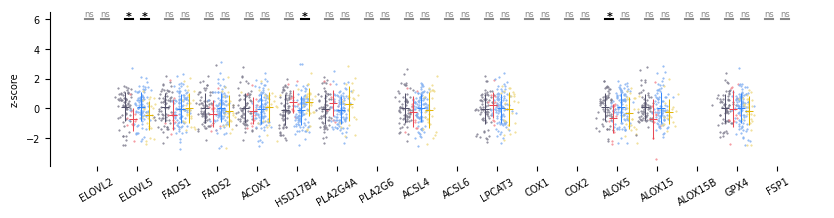

In [191]:
pzscores = (
    pdfp
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)

pzsf = {
    (g, r, m): z
    for g, r, m, z in pzscores.iter_rows()
}

ppvf = {}
for gene in pufa_genes:
    for race in ["black", "white"]:
        if (
            (zs_wt := pzsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := pzsf.get((gene, race, "NPM1"))) is not None
        ):
            ppvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

# # apply BH correction to ttest pvalues
# dpvf_keys, dpvf_values = map(list, zip(*dpvf.items()))
# dpvf = dict(zip(dpvf_keys, stats.false_discovery_control(dpvf_values)))

fig, ax = plt.subplots(
    figsize=(10, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(pufa_genes):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := pzsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := ppvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(pufa_genes))])
ax.set_xticklabels(pufa_genes, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_px_pufa-genes.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

---

In [7]:
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/928073276.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/928073276.py:3: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/928073276.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776660:W_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/353/174033353/W_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/928073276.py:7: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776659:W_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/684/172720684/W_NPM1-WT_mut-cols.txt, skipping download.


In [4]:
combined = pl.read_ipc(SYN.get(COMBINED_TABLE_SYN_ID).path)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/3275196554.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  combined = pl.read_ipc(SYN.get(COMBINED_TABLE_SYN_ID).path)



[syn74775996:combined_omics_data.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/712/172719712/combined_omics_data.arrow, skipping download.


In [14]:
bdfl = (
    combined
    .filter(pl.col("Block") == "Lipidomics")
    .select(
        pl.col("Feature").alias("Lipid"),
        *b_wt_cols,
        *b_mut_cols
    )
    .with_columns(
        # strip ionization mode off of the front and adduct off of the back of lipid IDs
        # and keep only the last annotation if multiple separated by |
        (
            pl.col("Lipid")
            .str.replace("[posneg]{3}_", "")
            .str.replace(r"_\[M[+-][H2ON4-]+\][+-].*", "")
            .str.split("|")
            .list.last()
            .str.replace("__[A-Z]+", "")
        ),
        (
            pl.col("Lipid")
            .str.extract(r"(\[M[+-][H2ON4-]+\][+-])")
            .fill_null("[M+H-H2O]+")
            .alias("Adduct")
        )
    )
    .select(
        "Lipid",
        "Adduct",
        pl.exclude("Lipid", "Adduct")
    )
)

wdfl = (
    combined
    .filter(pl.col("Block") == "Lipidomics")
    .select(
        pl.col("Feature").alias("Lipid"),
        *w_wt_cols,
        *w_mut_cols
    )
    .with_columns(
        # strip ionization mode off of the front and adduct off of the back of lipid IDs
        # and keep only the last annotation if multiple separated by |
        (
            pl.col("Lipid")
            .str.replace("[posneg]{3}_", "")
            .str.replace(r"_\[M[+-][H2ON4-]+\][+-].*", "")
            .str.split("|")
            .list.last()
            .str.replace("__[A-Z]+", "")
        ), 
        (
            pl.col("Lipid")
            .str.extract(r"(\[M[+-][H2ON4-]+\][+-])")
            .fill_null("[M+H-H2O]+")
            .alias("Adduct")
        )
    )
    .select(
        "Lipid",
        "Adduct",
        pl.exclude("Lipid", "Adduct")
    )
)

In [15]:
bdfl

Lipid,Adduct,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""LPI 20:4""","""[M-H]-""",18.521233,null,18.193435,null,17.372838,17.447092,17.915784,18.407116,17.201393,17.343284,18.072983,18.09385,17.167434,17.815893,18.144107,19.35725,17.466654,17.186804,18.437086,17.713872,18.847794,18.949739,19.472582,18.799535,18.513585,19.113846,17.973327,18.776077,18.662125,18.708151,19.131274,18.805877,18.935812,17.861215,18.223849,…,18.55596,18.341608,18.077672,18.578838,17.811048,19.113286,18.450712,19.576147,18.577926,19.203373,18.418395,19.543691,18.498732,17.829749,18.482629,19.391533,18.484184,19.836751,19.3081,19.960405,18.890469,19.661771,18.017436,17.74912,null,null,null,17.587865,18.450343,17.718724,18.24743,19.152533,18.605977,19.60444,17.940926,18.41998,18.106351
"""LPG 22:6""","""[M-H]-""",16.728723,null,16.357848,null,14.062908,14.660085,13.839148,15.295053,14.699496,16.057472,16.920046,15.909858,11.291285,15.056595,14.377889,16.168995,14.215011,16.029266,14.106974,15.287322,16.884587,17.087171,16.195006,16.341222,17.049902,17.267219,15.771117,17.395239,15.517584,17.079708,17.551123,16.567689,14.803822,14.532223,15.192167,…,16.635205,15.728894,15.704383,12.366509,14.53959,14.751594,14.924854,17.251664,16.156685,15.6784,15.550851,15.05062,14.902869,14.873261,15.699975,15.817997,14.571661,17.386041,15.985735,15.874988,13.960873,16.131771,16.441152,14.292429,null,null,null,12.896937,15.912913,15.113293,16.348064,15.720675,14.028547,16.471592,16.175151,15.399837,15.759151
"""LPI 20:3""","""[M-H]-""",17.119559,null,16.397039,null,16.588011,null,null,15.398115,15.507567,null,16.242012,15.368405,15.004633,15.838628,14.919043,17.502062,15.050656,14.96511,15.571739,15.277685,16.838498,16.793991,16.707387,15.674278,16.583885,16.968895,15.028793,16.697448,16.429732,16.257867,16.321945,18.246241,16.475857,15.854606,15.993678,…,16.141265,16.33835,14.860501,14.443014,15.55696,17.440327,15.318647,16.40874,15.885451,16.256813,16.821187,17.129637,16.32634,15.734148,16.010061,16.0695,16.544431,17.576433,15.959191,17.261699,15.243556,17.929766,16.432638,15.36772,null,null,null,null,15.076444,16.149264,16.662644,15.539793,16.412066,16.793265,15.745424,16.299807,16.173271
"""LPG 22:5""","""[M-H]-""",15.115795,null,16.026941,null,13.896452,14.132808,15.26759,16.005721,15.418413,17.129548,15.509279,17.063393,11.991379,15.319853,15.327093,16.175442,16.277012,15.903623,16.070613,15.56203,16.264481,16.67529,16.380533,15.616038,16.487267,17.019949,17.134589,16.907123,16.322902,17.435875,16.409388,16.754494,16.294899,15.219065,16.881615,…,16.8982,14.736249,16.587611,14.986736,14.777519,16.459432,16.529093,16.090827,17.07257,16.015243,15.533645,16.600648,14.978153,14.798952,16.337213,16.186979,16.157021,17.680115,16.401125,15.213555,15.07688,15.174771,15.261445,15.293843,null,null,null,13.16624,16.551705,16.322358,16.309982,17.112847,15.642926,17.069414,15.63467,15.7259,16.57144
"""LPI 18:1""","""[M-H]-""",16.654092,null,15.921247,null,null,null,null,15.820189,null,null,17.131718,15.796673,14.686516,13.7

In [16]:
wdfl

Lipid,Adduct,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,…,18-00290,18-00408,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""LPI 20:4""","""[M-H]-""",17.06623,19.026417,19.132243,18.50886,18.105979,17.44444,18.842996,19.559651,18.219809,18.672364,19.43877,19.45546,18.349313,18.519528,17.802095,18.541147,19.196469,19.31661,18.923942,18.494308,18.216189,null,17.683837,18.845469,18.926527,19.040346,18.288485,19.107699,null,null,null,18.865354,null,null,null,…,null,null,null,null,17.194406,null,null,null,null,null,null,null,null,19.008276,18.039241,17.776844,18.57031,18.224749,18.598928,18.20474,18.577863,19.01246,19.09918,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""LPG 22:6""","""[M-H]-""",15.420531,13.334115,15.474534,16.326141,16.0001,15.58053,15.492523,15.283197,17.608738,14.006904,17.539364,14.8406,15.657588,15.697298,14.811687,16.773126,16.074831,15.136944,15.886337,17.237736,15.897827,null,16.173315,15.340638,14.658011,16.803623,16.638905,16.229595,null,null,null,16.312413,null,null,null,…,null,null,null,null,14.875027,null,null,null,null,null,null,null,null,14.767001,16.103162,14.974481,13.274243,15.689124,15.829979,16.202822,12.551507,17.039769,15.947893,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""LPI 20:3""","""[M-H]-""",14.754988,16.349948,15.084179,14.670533,16.073114,15.737933,17.352397,15.508878,15.380796,16.06156,16.168749,16.529522,15.116977,16.150928,15.8934,17.554039,15.810008,16.181768,16.366863,16.628412,16.731942,null,16.007437,16.458577,16.020516,15.819757,15.56176,16.113821,null,null,null,17.308161,null,null,null,…,null,null,null,null,15.267321,null,null,null,null,null,null,null,null,17.480965,17.52108,14.767972,16.196002,15.495628,15.841575,15.34494,15.667541,17.132155,17.022376,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""LPG 22:5""","""[M-H]-""",15.261179,14.097894,15.404731,17.375415,14.860855,14.881498,17.308422,16.559035,16.409417,16.231318,17.027156,15.751845,15.196263,16.36303,16.330364,16.842767,17.3912,15.766673,15.718442,17.240461,17.895024,null,15.37606,15.457635,16.756719,15.190506,18.400535,17.146048,null,null,null,16.238668,null,null,null,…,null,null,null,null,15.82854,null,null,null,null,null,null,null,null,14.927514,16.054884,15.875988,15.672194,15.101946,15.21052,15.708507,14.850568,17.312172,15.676567,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""LPI 18:1""","""[M-H]-""",16.160669,16.827859,16.693898,17.399683,17.156942,17.431466,14.976591,17.668688,15.440685,16.144376,15.54409,17.511476,15.656484,13.915768,16.082863,14.415237,17.217237,16.608455,16.544141,16.587284,16.237703,null,16.990918,17.143718,15.715973,15.857491,15.983034,16.626778,null,null,null,15.634477,null,null,null,…,null,null,null,null,16.215976,null,null,null,null,null,null,null,null,17.387316,15.142961,15.278074,16.978437,16.188134,16.712968,17.080619,17.178773,15.263897,18.20379,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [52]:
(
    bdfl.filter(
        pl.col("Lipid")
        .str.contains("20:4")
    )
    .select(
        (
            pl.col("Lipid")
            .str.split(" ")
            .list.first()
            .alias("class")
        ),
        (
            pl.col("Lipid")
            .str.extract(
                r"[A-Za-z]+ (([OP])-)*.+", 
                group_index=2
            )
            .alias("fa_mod")
        ),
        "Lipid"
    )
    .group_by("class", "fa_mod")
    .len()
)

class,fa_mod,len
str,str,u32
"""PI""","""O""",2
"""LPC""",null,2
"""PS""",null,2
"""PC""",null,3
"""PE""",null,6
…,…,…
"""PC""","""O""",7
"""PE""","""P""",6
"""PE""","""O""",2


In [53]:
(
    bdfl.filter(
        pl.col("Lipid")
        .str.contains("22:6")
    )
    .select(
        (
            pl.col("Lipid")
            .str.split(" ")
            .list.first()
            .alias("class")
        ),
        (
            pl.col("Lipid")
            .str.extract(
                r"[A-Za-z]+ (([OP])-)*.+", 
                group_index=2
            )
            .alias("fa_mod")
        ),
        "Lipid"
    )
    .group_by("class", "fa_mod")
    .len()
)

class,fa_mod,len
str,str,u32
"""PG""",null,8
"""LPC""",null,2
"""PC""","""O""",2
"""LPE""",null,2
"""PI""",null,2
"""PE""","""P""",2
"""LPG""",null,1
"""PC""",null,1
"""PS""",null,2


In [123]:
# from: 
#   Quehenberger, et al. Journal of Lipid Research 
#   Volume 51, 2010. DOI: 10.1194/jlr.M009449
# LIT_LIPID_MOL_FRACS = {
#     "FA": 0.0267,
#     "TG": 0.1219,
#     "DG": 0.0065,
#     "PE": 0.0542,
#     "LPE": 0.0046,
#     "PC": 0.2460,
#     "LPC": 0.0128,
#     "PS": 0.0009,
#     "PG": 0.0008,
#     "PA": 0.0003,
#     "PI": 0.0039,
#     "SM": 0.0378,
#     "Cer": 0.0014
# }

# use this to perform no differential weighting of lipid classes
LIT_LIPID_MOL_FRACS = {
    "FA": 1.,
    "TG": 1.,
    "DG": 1.,
    "PE": 1.,
    "LPE": 1.,
    "PC": 1.,
    "LPC": 1.,
    "PS": 1.,
    "PG": 1.,
    "PA": 1.,
    "PI": 1.,
    "SM": 1.,
    "Cer": 1.
}

In [130]:
def reweight_lipids_by_class(df, sample_cols):
    # 1. Melt to long format: one row per (lipid, sample)
    long = (
        df
        .drop("Adduct")
        .group_by("Lipid")
        .agg(pl.exclude("Lipid").sum())
        # pull out lipid class and FA modifier
        .with_columns(
            pl.col("Lipid")
                .str.split(" ")
                .list.first()
                .alias("class"),
            pl.col("Lipid")
                .str.extract(r"^[A-Za-z]+ ([OP])-", group_index=1)
                .alias("fa_mod"),   # null when no O- or P- prefix
        )
        .unpivot(
            index=["Lipid", "class", "fa_mod"],
            on=sample_cols,
            variable_name="sample",
            value_name="abundance",
        )
    )

    # 2. Per-(sample, class) total — median across ALL fa_mod sub-groups
    #    so that mol fraction is distributed across the whole class
    class_totals = (
        long
        .group_by(["sample", "class"])
        .agg(pl.col("abundance").sum().alias("class_total"))
    )

    # 3. Literature mol fractions keyed on class
    mol_fracs = pl.DataFrame({
        "class": list(LIT_LIPID_MOL_FRACS.keys()),
        "mol_fraction": list(LIT_LIPID_MOL_FRACS.values()),
    })

    # 4. Per-(sample, class) weight = mol_fraction / class_total
    weights = (
        class_totals
        .filter(pl.col("class_total") > 0.0)
        #.join(mol_fracs, on="class", how="inner")  # drops classes w/o lit values
        .with_columns(
            (1. / pl.col("class_total")).alias("weight")
        )
        .select(["sample", "class", "weight"])
    )

    # 5. Apply weights: weighted_abundance = abundance * weight
    long_weighted = (
        long
        .join(weights, on=["sample", "class"], how="inner")
        .with_columns(
            (pl.col("abundance") * pl.col("weight")).alias("weighted_abundance")
        )
        .select("Lipid", "sample", "weighted_abundance")
    )

    return long_weighted

In [131]:
bdflw = reweight_lipids_by_class(bdfl, b_wt_cols + b_mut_cols)
bdflw

Lipid,sample,weighted_abundance
str,str,f64
"""CAR 18:0""","""14-00240""",0.044834
"""Cer 19:1;O2/24:1""","""14-00240""",0.061937
"""Cer 18:1;O2/20:0""","""14-00240""",0.023756
"""PC O-18:1_22:6""","""14-00240""",0.075733
"""CAR 20:0""","""14-00240""",0.039298
…,…,…
"""LPC 24:1/0:0""","""C-01-0930""",0.017602
"""Cer 18:0;O2/24:0""","""C-01-0930""",0.039073
"""PC O-16:1_20:4""","""C-01-0930""",0.037371


In [146]:
bdflwr = (
    bdflw
    .filter(
        pl.col("Lipid")
        .str.contains("20:4")
    )
    .group_by("sample")
    .agg(pl.col("weighted_abundance").sum().alias("ARA"))
    .join(
        (
            bdflw
            .filter(
                pl.col("Lipid")
                .str.contains("22:6")
            )
            .group_by("sample")
            .agg(pl.col("weighted_abundance").sum().alias("DHA"))
        ),
        on="sample",
        how="inner"
    )
    .with_columns(
        (pl.col("ARA") / pl.col("DHA"))
        .alias("ratio")
    )
)
bdflwr

sample,ARA,DHA,ratio
str,f64,f64,f64
"""C-98-0454""",2.305296,0.929122,2.481154
"""C-03-2056""",2.276096,0.860286,2.645743
"""C-07-2070""",2.362528,0.899192,2.62739
"""C-05-2448""",2.326624,0.884642,2.630016
"""C-09-5381""",2.319522,0.912662,2.541492
…,…,…,…
"""C-09-1906""",2.308784,0.881666,2.618662
"""C-97-0509""",2.322674,0.878401,2.644206
"""C-09-1074""",2.33539,0.885231,2.638171


In [141]:
wdflw = reweight_lipids_by_class(wdfl, w_wt_cols + w_mut_cols)
wdflw

Lipid,sample,weighted_abundance
str,str,f64
"""LPG 22:5""","""13-00033""",0.137639
"""LPC 18:1""","""13-00033""",0.029035
"""Cer 18:1;O2/20:0""","""13-00033""",0.023834
"""PE P-16:0_18:1""","""13-00033""",0.03567
"""LPS 18:1""","""13-00033""",1.0
…,…,…
"""LPC 14:0""","""15-00276""",0.023045
"""DG 18:1_18:2""","""15-00276""",0.255323
"""CAR 14:0""","""15-00276""",0.039724


In [147]:
wdflwr = (
    wdflw
    .filter(
        pl.col("Lipid")
        .str.contains("20:4")
    )
    .group_by("sample")
    .agg(pl.col("weighted_abundance").sum().alias("ARA"))
    .join(
        (
            wdflw
            .filter(
                pl.col("Lipid")
                .str.contains("22:6")
            )
            .group_by("sample")
            .agg(pl.col("weighted_abundance").sum().alias("DHA"))
        ),
        on="sample",
        how="inner"
    )
    .with_columns(
        (pl.col("ARA") / pl.col("DHA"))
        .alias("ratio")
    )
)
wdflwr

sample,ARA,DHA,ratio
str,f64,f64,f64
"""14-00127""",2.376153,0.917016,2.59118
"""13-00331""",2.307247,0.906309,2.545762
"""15-00043""",2.317821,0.856832,2.705104
"""14-00514""",2.392366,0.900992,2.655258
"""15-00051""",2.323529,0.830858,2.796541
…,…,…,…
"""14-00092""",2.326927,0.916117,2.539988
"""15-00287""",2.338129,0.841663,2.777986
"""13-00033""",2.29175,0.881208,2.600691


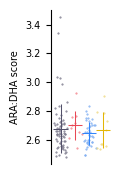

In [149]:
pzsf = {
    ("black", "WT"): (
        bdflwr
        .filter(pl.col("sample").is_in(b_wt_cols))
        ["ratio"]
        .to_list()
    ),
    ("black", "NPM1"): (
        bdflwr
        .filter(pl.col("sample").is_in(b_mut_cols))
        ["ratio"]
        .to_list()
    ),
    ("white", "WT"): (
        wdflwr
        .filter(pl.col("sample").is_in(w_wt_cols))
        ["ratio"]
        .to_list()
    ),
    ("white", "NPM1"): (
        wdflwr
        .filter(pl.col("sample").is_in(w_mut_cols))
        ["ratio"]
        .to_list()
    )
}

fig, ax = plt.subplots(
    figsize=(0.8, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)
x_center = 0
x_center = x_center + 1 - 1.5 * x_off
for race in ["black", "white"]:
    for mut in ["WT", "NPM1"]:
        if (zs := pzsf.get((race, mut))) is not None:
            ax.errorbar(
                x_center,
                np.mean(zs),
                yerr=np.std(zs),
                xerr=bw,
                ecolor=C["bar"][(race, mut)],
                elinewidth=0.75
            )
            swarm(ax, x_center, zs, C["swarm"][(race, mut)], sd=0.05)
        x_center += x_off

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([])


ax.set_ylabel("ARA:DHA score")
plt.savefig(
    os.path.join(FIGURE_DIR, "ara-dha-score-ratios.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)

plt.show()
plt.close()

---

In [150]:
bdfm = (
    combined
    .filter(pl.col("Block") == "Metabolomics")
    .select(
        pl.col("Feature").alias("Metabolite"),
        *b_wt_cols,
        *b_mut_cols
    )
)

In [151]:
wdfm = (
    combined
    .filter(pl.col("Block") == "Metabolomics")
    .select(
        pl.col("Feature").alias("Metabolite"),
        *w_wt_cols,
        *w_mut_cols
    )
)

In [152]:
(
    bdfm
    .filter(
        pl.col("Metabolite")
        .str.contains("acid")
    )
)

Metabolite,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Diatrizoic.acid""",18.313026,null,19.319822,null,18.700301,19.171562,18.062871,17.615562,21.113868,17.458424,18.042996,18.733708,23.851773,18.488582,20.250082,18.252482,18.432648,21.041438,17.420584,20.19473,18.875618,19.452449,19.657696,16.423522,19.458517,19.287576,20.133936,19.460615,19.103545,20.733953,19.624519,18.778998,19.405727,21.54382,21.295644,21.262916,…,20.925102,18.679728,20.611913,20.950643,19.254765,19.49595,20.310744,21.371787,21.895538,20.385784,21.258935,21.059893,23.131042,21.955899,21.82768,21.501988,20.257416,20.784584,22.35821,22.118794,22.165694,20.095193,20.701507,21.644519,null,null,null,17.590552,18.950005,16.443533,20.921529,18.850461,18.805984,18.941346,21.260814,19.664376,21.133804
"""rpneg_2.Hydroxyglutaric.acid""",24.710778,null,19.121279,null,20.582982,20.321719,19.841943,25.120547,19.887575,20.003366,20.004716,20.08044,21.268452,19.302909,20.022407,19.45919,21.298816,20.011899,22.793297,21.168383,19.031186,18.651058,19.669363,18.999761,18.541692,18.614761,18.944992,18.889188,19.605048,19.21998,18.979831,19.415004,18.238723,19.908741,19.104192,18.978698,…,18.440255,18.944446,26.293011,15.656827,18.402394,24.876595,18.888554,19.651903,18.911365,19.251775,18.841156,19.414443,19.73593,19.197231,19.158017,18.973608,18.26126,19.241572,19.76266,19.018977,20.236164,19.66297,19.064436,27.476016,null,null,null,20.259113,21.137191,21.390831,18.866432,23.589654,18.673752,18.080424,26.823476,18.82074,19.74682
"""rpneg_Arachidonic.acid""",14.508916,null,17.917433,null,13.905683,14.849152,15.738563,17.575966,16.703542,18.517478,17.411253,17.507195,17.414994,18.101278,17.807332,17.729399,17.387893,18.05674,17.234774,17.502492,17.847465,18.019534,17.189534,17.089302,15.98753,17.070654,17.92678,16.397605,17.110236,17.119866,17.88624,16.644936,17.539995,18.826434,16.825493,17.017768,…,18.192865,17.343492,17.323432,17.547451,16.402457,17.734074,17.577093,15.587368,17.139572,15.844553,17.614843,16.798121,15.481156,16.543478,17.157544,16.310184,17.473539,17.811844,15.779748,17.654044,16.404872,17.2637,16.404632,16.0697,null,null,null,15.826263,17.222089,18.146587,17.976356,17.298797,17.542371,16.603662,17.242366,18.948991,15.856497
"""rpneg_Citraconic.acid""",23.034946,null,20.737356,null,20.526132,21.479628,22.52398,22.517933,20.284357,23.484812,20.634386,20.737394,21.089478,19.944594,22.791153,19.924156,20.757316,20.640119,21.257008,20.552784,20.017231,19.860184,20.504204,19.527014,19.881744,20.062662,22.199871,19.512964,20.137384,20.312067,19.84218,20.392636,18.742418,21.044781,20.002941,19.744223,…,19.50581,19.371498,23.329791,19.37511,19.899041,22.254518,18.988132,19.413858,19.180951,19.268243,18.488955,19.680658,19.470245,19.44374,19.216846,18.956257,19.069087,19.236359,18.79637,17.923273,18.702835,18.728118,18.784739,24.715749,null,null,null,21.341232,20.603353,20.50199,20.489319,21.387507,19.789585,19.474152,23.782456,18.99632,19.329519
"""rpneg_Citric.acid""",24.499021,null,23.903136

In [33]:
(
    bdfm
    .filter(
        pl.col("Metabolite") == "rpneg_Arachidonic.acid"
    )
)

Metabolite,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rpneg_Arachidonic.acid""",14.508916,null,17.917433,null,13.905683,14.849152,15.738563,17.575966,16.703542,18.517478,17.411253,17.507195,17.414994,18.101278,17.807332,17.729399,17.387893,18.05674,17.234774,17.502492,17.847465,18.019534,17.189534,17.089302,15.98753,17.070654,17.92678,16.397605,17.110236,17.119866,17.88624,16.644936,17.539995,18.826434,16.825493,17.017768,…,18.192865,17.343492,17.323432,17.547451,16.402457,17.734074,17.577093,15.587368,17.139572,15.844553,17.614843,16.798121,15.481156,16.543478,17.157544,16.310184,17.473539,17.811844,15.779748,17.654044,16.404872,17.2637,16.404632,16.0697,null,null,null,15.826263,17.222089,18.146587,17.976356,17.298797,17.542371,16.603662,17.242366,18.948991,15.856497


In [36]:
(
    wdfm
    .filter(
        pl.col("Metabolite") == "rpneg_Arachidonic.acid"
    )
)

Metabolite,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,18-00290,18-00408,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rpneg_Arachidonic.acid""",16.881817,20.095285,16.426405,17.273985,16.14587,16.683044,17.414499,16.823289,17.337089,16.574004,17.157415,17.543339,16.317329,16.90651,18.653006,16.590584,15.96977,17.886946,17.438003,17.000687,16.983418,null,17.024848,17.276357,17.483679,17.765869,16.293728,17.692927,null,null,null,17.071735,null,null,null,null,…,null,null,null,null,16.168275,null,null,null,null,null,null,null,null,15.687595,17.175165,17.761533,17.943173,17.096413,17.597517,17.812499,18.076591,15.971112,18.389945,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [161]:
ara_df

Race,Mutation,Z-score
str,str,list[f64]
"""white""","""WT""","[-0.277168, 3.321999, … -1.076353]"
"""white""","""NPM1""","[-1.614728, 0.051389, … 1.411973]"
"""black""","""WT""","[-2.712591, 0.905066, … -1.05604]"
"""black""","""NPM1""","[-1.314414, 0.167057, … -1.282325]"


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/4084595317.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/4084595317.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


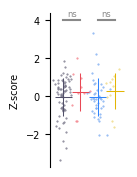

In [233]:
df_ara = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Metabolomics")
    .drop("Block")
    .rename({"Feature": "Metabolite"})
    .unpivot(
        index="Metabolite",
        variable_name="Sample",
        value_name="Z-score"
    )
    .filter(pl.col("Metabolite") == "rpneg_Arachidonic.acid")
    .with_columns(
        (
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols + b_wt_cols
                } | {
                    k: "NPM1"
                    for k in w_mut_cols + b_mut_cols
                }
            )
            .alias("Mutation")
        ),
        (
            pl.col("Sample")
            .replace(
                {
                    k: "black"
                    for k in b_wt_cols + b_mut_cols
                } | {
                    k: "white"
                    for k in w_wt_cols + w_mut_cols
                }
            )
            .alias("Race")
        )
    )
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Race", "Mutation")
    .agg("Z-score")
)

zsf = {
    (race, mutation): zscores
    for race, mutation, zscores in df_ara.iter_rows()
}

fig, ax = plt.subplots(
    figsize=(1, 2)
)

x_off = 0.2
bw = 0.1


pvf = {}
for race in ["black", "white"]:
    if (
        (zs_wt := zsf.get((race, "WT"))) is not None 
        and (zs_mut := zsf.get((race, "NPM1"))) is not None
    ):
        pvf[race] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

#ax.axhline(c="k", lw=1., zorder=-1)
x_center = 0
x_center = x_center + 1 - 1.5 * x_off
for race in ["black", "white"]:
    for mut in ["WT", "NPM1"]:
        if (zs := zsf.get((race, mut))) is not None:
            ax.errorbar(
                x_center,
                np.mean(zs),
                yerr=np.std(zs),
                xerr=bw,
                ecolor=C["bar"][(race, mut)],
                elinewidth=0.75
            )
            swarm(ax, x_center, zs, C["swarm"][(race, mut)], sd=0.05)
        x_center += x_off
    # annotate statistically significant comparisons between WT and mutant
    bc = "#898989"
    t = "ns"
    t_yoff = 0.2
    fs = 6
    fw = "normal"
    if (pv := pvf.get(race)) is not None and pv <= 0.05:
        t = "*"
        bc = "k"
        t_yoff = 0
        fs = 8
        fw = "bold"
    ax.text(
        x_center - 1.5 * x_off,
        4 + t_yoff,
        t,
        color=bc,
        ha="center",
        fontsize=fs,
        fontweight=fw
    )
    ax.plot(
        [x_center - 2 * x_off, x_center - x_off],
        [4, 4],
        c=bc,
        ls="-",
        lw=1.5
    )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([])


ax.set_ylabel("Z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "ara_metabolomics_zscores.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [208]:
# load the dataset
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

df_20_3 = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Lipidomics")
    .drop("Block")
    #.rename({"Feature": "Gene"})
    .filter(
        pl.col("Feature").str.contains("FA ")
    )
    .unpivot(
        index="Feature",
        variable_name="Sample",
        value_name="Z-score"
    )
    .with_columns(
        (
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols + b_wt_cols
                } | {
                    k: "NPM1"
                    for k in w_mut_cols + b_mut_cols
                }
            )
            .alias("Mutation")
        ),
        (
            pl.col("Sample")
            .replace(
                {
                    k: "black"
                    for k in b_wt_cols + b_mut_cols
                } | {
                    k: "white"
                    for k in w_wt_cols + w_mut_cols
                }
            )
            .alias("Race")
        )
    )
    .filter(pl.col("Z-score").is_not_null())
)
df_20_3

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1102844717.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1102844717.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1102844717.py:6: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1102844717.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1102844717.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Feature,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""neg_FA 20:3_[M-H]-__A""","""14-00240""",0.521688,"""WT""","""black"""
"""neg_FA 20:3_[M-H]-__B""","""14-00240""",1.34372,"""WT""","""black"""
"""neg_FA 20:3_[M-H]-__A""","""16-01109""",0.217513,"""WT""","""black"""
"""neg_FA 20:3_[M-H]-__B""","""16-01109""",0.767522,"""WT""","""black"""
"""neg_FA 20:3_[M-H]-__A""","""C-05-0664""",-1.738116,"""WT""","""black"""
…,…,…,…,…
"""neg_FA 20:3_[M-H]-__B""","""15-00051""",-0.690961,"""NPM1""","""white"""
"""neg_FA 20:3_[M-H]-__A""","""14-00083""",1.902412,"""NPM1""","""white"""
"""neg_FA 20:3_[M-H]-__B""","""14-00083""",0.512726,"""NPM1""","""white"""


In [ ]:
df_20_3.select(pl.col("Feature").unique())

Feature
str
"""neg_FA 20:3_[M-H]-__B"""
"""neg_FA 20:3_[M-H]-__A"""


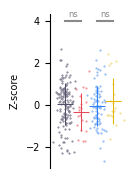

In [173]:
zsf = {
    (race, mutation): zscores
    for race, mutation, zscores in (
        df
        .group_by("Race", "Mutation")
        .agg("Z-score")
        .iter_rows()
    )
}

fig, ax = plt.subplots(
    figsize=(1, 2)
)

x_off = 0.2
bw = 0.1


pvf = {}
for race in ["black", "white"]:
    if (
        (zs_wt := zsf.get((race, "WT"))) is not None 
        and (zs_mut := zsf.get((race, "NPM1"))) is not None
    ):
        pvf[race] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

#ax.axhline(c="k", lw=1., zorder=-1)
x_center = 0
x_center = x_center + 1 - 1.5 * x_off
for race in ["black", "white"]:
    for mut in ["WT", "NPM1"]:
        if (zs := zsf.get((race, mut))) is not None:
            ax.errorbar(
                x_center,
                np.mean(zs),
                yerr=np.std(zs),
                xerr=bw,
                ecolor=C["bar"][(race, mut)],
                elinewidth=0.75
            )
            swarm(ax, x_center, zs, C["swarm"][(race, mut)], sd=0.05)
        x_center += x_off
    # annotate statistically significant comparisons between WT and mutant
    bc = "#898989"
    t = "ns"
    t_yoff = 0.2
    fs = 6
    fw = "normal"
    if (pv := pvf.get(race)) is not None and pv <= 0.05:
        t = "*"
        bc = "k"
        t_yoff = 0
        fs = 8
        fw = "bold"
    ax.text(
        x_center - 1.5 * x_off,
        4 + t_yoff,
        t,
        color=bc,
        ha="center",
        fontsize=fs,
        fontweight=fw
    )
    ax.plot(
        [x_center - 2 * x_off, x_center - x_off],
        [4, 4],
        c=bc,
        ls="-",
        lw=1.5
    )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([])


ax.set_ylabel("Z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "FA_20-3_DHGLA_lipidomics_zscores.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)

plt.show()
plt.close()

---
make a big set of bars and plot out the ∆z scores for all of the ARA/DHA lipid metabolism related features

In [201]:
prot_dzb_dzw = (
    pdfp
    .group_by("Gene", "Mutation", "Race")
    .agg(pl.col("Z-score").mean())
    .pivot(
        on="Mutation",
        index=["Gene", "Race"],
        values="Z-score"
    )
    .select(
        "Gene",
        "Race",
        (pl.col("NPM1") - pl.col("WT")).alias("dZ")
    )
    .pivot(
        on="Race", 
        index="Gene",
        values="dZ"
    )
    .rename({
        "Gene": "Feature", 
        "black": "dz_b", 
        "white": "dz_w"
    })
)

In [227]:
df_20_3_dzb_dzw = (
    df_20_3
    .group_by("Mutation", "Race")
    .agg(pl.col("Z-score").mean())
    .pivot(
        on="Mutation", 
        index="Race",
        values="Z-score"
    )
    .select(
        pl.lit("FA 20:3").alias("Feature"),
        "Race",
        (pl.col("NPM1") - pl.col("WT")).alias("dZ")
    )
    .pivot(
        on="Race",
        index="Feature",
        values="dZ"
    )
    .rename({
        "black": "dz_b", 
        "white": "dz_w"
    })
)

In [239]:
ara_dzb_dzw = (
    df_ara
    .with_columns(pl.col("Z-score").list.mean())
    .pivot(
        on="Mutation", 
        index="Race",
        values="Z-score"
    )
    .select(
        pl.lit("FA 20:4").alias("Feature"),
        "Race",
        (pl.col("NPM1") - pl.col("WT")).alias("dZ")
    )
    .pivot(
        on="Race",
        index="Feature",
        values="dZ"
    )
    .rename({
        "black": "dz_b", 
        "white": "dz_w"
    })
)

In [ ]:
df_lipid_z = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Lipidomics")
    .drop("Block")
    .rename({"Feature": "Lipid"})
    .unpivot(
        index="Lipid",
        variable_name="Sample",
        value_name="Z-score"
    )
    .with_columns(
        (
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols + b_wt_cols
                } | {
                    k: "NPM1"
                    for k in w_mut_cols + b_mut_cols
                }
            )
            .alias("Mutation")
        ),
        (
            pl.col("Sample")
            .replace(
                {
                    k: "black"
                    for k in b_wt_cols + b_mut_cols
                } | {
                    k: "white"
                    for k in w_wt_cols + w_mut_cols
                }
            )
            .alias("Race")
        )
    )
    .with_columns(
        # strip ionization mode off of the front and adduct off of the back of lipid IDs
        # and keep only the last annotation if multiple separated by |
        (
            pl.col("Lipid")
            .str.replace("[posneg]{3}_", "")
            .str.replace(r"_\[M[+-][H2ON4-]+\][+-].*", "")
            .str.split("|")
            .list.last()
            .str.replace("__[A-Z]+", "")
        ),
        (
            pl.col("Lipid")
            .str.extract(r"(\[M[+-][H2ON4-]+\][+-])")
            .fill_null("[M+H-H2O]+")
            .alias("Adduct")
        ),
    )
    .with_columns(
        (
            pl.col("Lipid")
            .str.split(" ")
            .list.first()
            .alias("class")
        ),
        (
            pl.col("Lipid")
            .str.extract(r"^[A-Za-z]+ ([OP])-", group_index=1)
            .alias("fa_mod")
        )
    )
    .filter(pl.col("Z-score").is_not_null())
)
df_lipid_z

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1401634177.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23238/1401634177.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Lipid,Sample,Z-score,Mutation,Race,Adduct,class,fa_mod
str,str,f64,str,str,str,str,str
"""LPI 20:4""","""14-00240""",-0.01228,"""WT""","""black""","""[M-H]-""","""LPI""",null
"""LPG 22:6""","""14-00240""",0.989119,"""WT""","""black""","""[M-H]-""","""LPG""",null
"""LPI 20:3""","""14-00240""",1.013562,"""WT""","""black""","""[M-H]-""","""LPI""",null
"""LPG 22:5""","""14-00240""",-0.889532,"""WT""","""black""","""[M-H]-""","""LPG""",null
"""LPI 18:1""","""14-00240""",0.243035,"""WT""","""black""","""[M-H]-""","""LPI""",null
…,…,…,…,…,…,…,…
"""Cer 19:1;O2/24:1""","""15-00276""",-0.465244,"""NPM1""","""white""","""[M+H-H2O]+""","""Cer""",null
"""Cer 18:1;O2/26:1""","""15-00276""",-2.468304,"""NPM1""","""white""","""[M+H-H2O]+""","""Cer""",null
"""HexCer 18:1;O2/22:1""","""15-00276""",-0.071704,"""NPM1""","""white""","""[M+H-H2O]+""","""HexCer""",null


In [269]:
with pl.Config(set_tbl_rows=35): 
    display(df_lipid_z.group_by("class", "fa_mod").len().sort("len"))

class,fa_mod,len
str,str,u32
"""CE""",null,106
"""Hex3Cer""",null,129
"""CoQ10""",null,129
"""LPC""","""O""",129
"""LPE""","""O""",129
"""CoQ9""",null,129
"""CL""",null,129
"""LPS""",null,129
"""Hex2Cer""",null,129


In [286]:
lipid_groups = [
    ("PC", "", "20:4", f"PC 20:4_X:X"),
    ("LPC", "", "20:4", "LPC 20:4"),
    ("PC", "O", "20:4", "PC O-20:4_X:X"),
    ("PE", "", "20:4", "PE 20:4_X:X"),
    ("LPE", "", "20:4", "LPE 20:4"),
    ("PE", "O", "20:4", "PE O-20:4_X:X"),
    ("PE", "P", "20:4", "PE P-20:4_X:X"),
    ("PI", "", "20:4", f"PI 20:4_X:X"),
    ("PC", "", "22:6", f"PC 22:6_X:X"),
    ("LPC", "", "22:6", f"LPC 22:6"),
    ("PC", "O", "22:6", "PC O-22:6_X:X"),
    #("PE", "", "22:6", "PE 22:6_X:X"),
    ("LPE", "", "22:6", "LPE 22:6"),
    #("PE", "O", "22:6", "PE O-22:6_X:X"),
    ("PE", "P", "22:6", "PE P-22:6_X:X"),
    ("PI", "", "22:6", f"PI 22:6_X:X"),
]

lipid_group_dzb_dzw = pl.concat(
    [
        (
            df_lipid_z
            .with_columns(pl.col("fa_mod").fill_null(""))
            .filter(
                (pl.col("class") == cl)
                & (pl.col("fa_mod") == fm)
                & (pl.col("Lipid").str.contains(fa))
            )
            .group_by("Race", "Mutation")
            .agg(pl.col("Z-score").mean())
            .pivot(
                on="Mutation",
                index="Race",
                values="Z-score"
            )
            .select(
                pl.lit(gn).alias("Feature"),
                "Race",
                (pl.col("NPM1") - pl.col("WT")).alias("dZ")
            )
            .pivot(
                on="Race",
                index="Feature",
                values="dZ"
            )
            .rename({
                "black": "dz_b", 
                "white": "dz_w"
            })
        )
        for cl, fm, fa, gn in lipid_groups
    ],
    how="diagonal"
)

with pl.Config(set_tbl_rows=35): 
    display(lipid_group_dzb_dzw)

Feature,dz_b,dz_w
str,f64,f64
"""PC 20:4_X:X""",0.389733,-0.089584
"""LPC 20:4""",0.195726,-0.112003
"""PC O-20:4_X:X""",0.101445,0.083495
"""PE 20:4_X:X""",0.552876,0.125953
"""LPE 20:4""",0.134849,0.69989
"""PE O-20:4_X:X""",0.803406,0.275576
"""PE P-20:4_X:X""",0.864461,0.632212
"""PI 20:4_X:X""",-0.217186,0.017001
"""PC 22:6_X:X""",0.392348,-0.102559


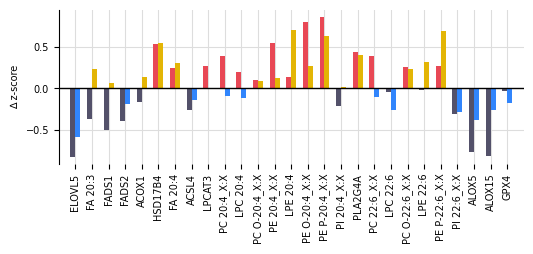

In [291]:
fig, ax = plt.subplots(
    figsize=(6, 2)
)

bw = 0.3


# will be selected and plotted in this order
features_in_order = [
    # FA metabolism
    "ELOVL5", "FA 20:3", "FADS1", "FADS2", "ACOX1", "HSD17B4",
    # lipid remodeling
    "FA 20:4",
    "ACSL4", "LPCAT3", 
    "PC 20:4_X:X", "LPC 20:4", "PC O-20:4_X:X", 
    "PE 20:4_X:X", "LPE 20:4", "PE O-20:4_X:X", "PE P-20:4_X:X",
    "PI 20:4_X:X",
    "PLA2G4A", 
    "PC 22:6_X:X", "LPC 22:6", "PC O-22:6_X:X", 
    "LPE 22:6", "PE P-22:6_X:X",
    "PI 22:6_X:X",
    # activation
    "ALOX5", "ALOX15",
    # detoxificaiton
    "GPX4"
]

# columns: feature, dz_b, dz_w
# add row index starting at 1
_df = (
    pl.concat([
        prot_dzb_dzw,
        df_20_3_dzb_dzw,
        ara_dzb_dzw,
        lipid_group_dzb_dzw
    ], how="diagonal")
    .filter(pl.col("Feature").is_in(features_in_order))
    .sort(pl.col("Feature").replace_strict({f: i for i, f in enumerate(features_in_order)}))
    .select("Feature", "dz_b", "dz_w")
    .with_row_index(offset=1)
)


c_b = [
    C["bar"][("black", ("NPM1" if dz_b > 0 else "WT"))]
    for dz_b in _df["dz_b"]
]
c_w = [
    C["bar"][("white", ("NPM1" if dz_w > 0 else "WT"))]
    for dz_w in _df["dz_w"]
]

ax.bar(
    _df["index"],
    _df["dz_b"],
    color=c_b,
    width=-bw,
    align="edge",
    zorder=10,
)
ax.bar(
    _df["index"],
    _df["dz_w"],
    color=c_w,
    width=bw,
    align="edge",
    zorder=10,
)
        
for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xlim((0, len(_df) + 1))
ax.set_xticks(_df["index"])
ax.set_xticklabels(_df["Feature"], rotation=90)

ax.grid(which="major", color="#DDDDDD")

ax.axhline(c="k", lw=1., zorder=11)

ax.set_ylabel("∆ z-score")

plt.savefig(
    os.path.join(FIGURE_DIR, f"pufas_z_score_bars_all-features-across-omes.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()